# Predicting Student Exam Scores from Behavioral and Background Factors
**CMSC 320 — Introduction to Data Science | Spring 2026**

**Authors:** Eric Wen, Ali Nilforoushan

---

| Section | Contributor | Summary |
|---------|-------------|---------|
| A — Project Idea | Eric, Ali | Identified the research question and selected the dataset. |
| B — Dataset Curation & Preprocessing | Eric, Ali | Loaded the dataset, verified column types, and handled missing values. |
| C — Data Exploration & Summary Statistics | Ali | Designed and implemented all seven EDA plots and accompanying statistical tests. |
| D — ML Algorithm Design | Eric | Chose linear regression as the primary model and defined the feature set. |
| E — ML Training & Test Analysis | Eric | Implemented the train/test split, trained the model, and computed R² and RMSE. |
| F — Visualization, Result Analysis & Conclusion | Eric | Produced the prediction and residual plots and wrote the insights section. |
| G — Final Tutorial Report | Eric, Ali | Assembled the notebook, wrote all markdown prose, and reviewed the full pipeline. |

## Introduction

Student academic performance is shaped by a wide range of factors: from how many hours a student studies to whether they have internet access at home. But which of these factors actually matter, and by how much?

In this project, we analyze a dataset of high school student performance records to answer one central question: **can we predict a student's exam score from their behaviors and background?** Answering this has real practical value — if a model can reliably predict scores from behavioral and environmental factors, it gives educators an early signal to identify students who may need additional support before exams.

We approach this in two stages. First, we explore the data statistically to understand which features are actually related and influential to exam performance. Then, we use those features to train a linear regression model and evaluate how well it predicts exam scores.

## Data Curation

**Source:** [Student Performance Factors — Kaggle](https://www.kaggle.com/datasets/muhammadahmaddaar/student-performance-factors/data)

The dataset contains student records with 20 features covering study habits (`Hours_Studied`, `Attendance`, `Tutoring_Sessions`), home environment (`Parental_Involvement`, `Internet_Access`, `Family_Income`), and school-related factors (`Teacher_Quality`, `School_Type`). The target variable is `Exam_Score`, a numeric score representing student performance.

We load the data into a pandas DataFrame and check for missing values, noting that `Teacher_Quality`, `Parental_Education_Level`, and `Distance_from_Home` have a small number of missing entries, which we drop since they represent a negligible fraction of the dataset. All other columns are complete. We also verify that numeric columns have the correct types. 

Lastly, we drop the `Previous_Scores` column, due to the main ambiguity of when the scores were collected in relation to the other data.

In [375]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib import patches as mpatches
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Shared Style
BLUE   = '#3B82F6'
NAVY   = '#1225A0'
RED    = '#E21833'
YELLOW = '#FFD200'
GOLDEN = '#F39C12'
ORANGE = "#F26D0E"
GREEN  = '#10B981'
PURPLE = '#8B5CF6'
PINK   = "#F068AC"
GRAY   = '#6B7280'
BG     = '#F7FBFF'
DARK   = '#1E293B'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelcolor': DARK,
    'axes.titlecolor': DARK,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.titlelocation': 'center',
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'axes.axisbelow': True,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'axes.grid': False,
    'grid.color': '#E2E8F0',
    'grid.linewidth': 0.8,
})
alpha = 0.05

In [376]:
# Load dataset
df = pd.read_csv("perform.csv")

# Check for NaN and drop
print("Missing values per column:")
print(df.isna().sum())
print(f"\nRows before dropping NaN: {len(df)}")
df = df.dropna()
print(f"Rows after dropping NaN: {len(df)}")

# Verify Type
print(type(df.loc[0, "Hours_Studied"]))
print(type(df.loc[0, "Attendance"]))
print(type(df.loc[0, "Sleep_Hours"]))
print(type(df.loc[0, "Previous_Scores"]))
print(type(df.loc[0, "Tutoring_Sessions"]))
print(type(df.loc[0, "Physical_Activity"]))
print(type(df.loc[0, "Exam_Score"]))

# Drop Previous Scores column
df = df.drop(columns=['Previous_Scores'])

Missing values per column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Rows before dropping NaN: 6607
Rows after dropping NaN: 6378
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>


## Exploratory Data Analysis

Before building a predictive model, we need to understand the structure of the data and identify which features are meaningfully related to exam scores. This section presents seven visualizations covering continuous, categorical, and binary predictors. For each, we state a hypothesis, run a statistical test, and discuss the practical implications of our findings.

**Key takeaway upfront:** attendance and hours studied are the two strongest predictors of exam score among numeric variables. Among categorical/binary variables, parental involvement, motivation level, teacher quality, family income, internet access, learning disabilities, and extracurricular activities all show statistically significant associations with exam scores, though the effect sizes vary considerably.

### 1. Exam Score Distribution

Before examining what predicts exam scores, we first need to understand the distribution of the target variable itself. We use a histogram overlaid with a Kernel Density Estimate (KDE) to visualize the shape of the distribution.

The **mean** (red dashed line) and **median** (yellow dashed line) serve as reference points. If they are close together, the distribution is roughly symmetric.

=== Exam Score Summary Statistics ===
count    6378.000000
mean       67.252117
std         3.914217
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64
Skewness: 1.6658
Kurtosis: 10.6562


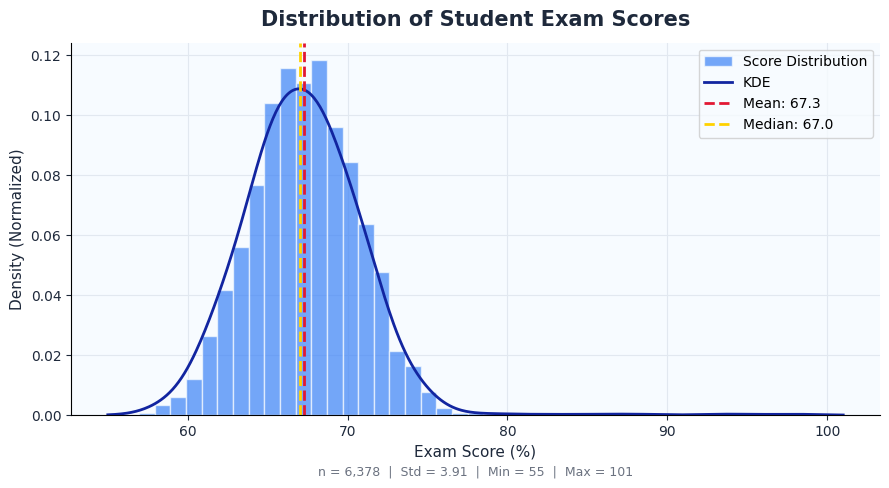

In [377]:
scores = df['Exam_Score']

# Summary Statistics and Distribution
print("=== Exam Score Summary Statistics ===")
print(scores.describe())
print(f"Skewness: {scores.skew():.4f}")
print(f"Kurtosis: {scores.kurtosis():.4f}")

# Data Histogram
plt.figure(figsize=(9, 5))
plt.hist(scores, bins=47, color=BLUE, alpha=0.7, edgecolor=BG,
        density=True, label='Score Distribution')

# KDE Plot
kde_x = np.linspace(scores.min(), scores.max(), 500)
plt.plot(kde_x, stats.gaussian_kde(scores, bw_method=0.3)(kde_x), color=NAVY, linewidth=2, label='KDE')

# Mean and Median lines
plt.axvline(scores.mean(),   color=RED,    linestyle='--', linewidth=2,
            label=f'Mean: {scores.mean():.1f}')
plt.axvline(scores.median(), color=YELLOW, linestyle='--', linewidth=2,
            label=f'Median: {scores.median():.1f}')

# Plot Design
plt.grid(True)
plt.title('Distribution of Student Exam Scores')
plt.xlabel('Exam Score (%)')
plt.ylabel('Density (Normalized)')
plt.legend()

# Distribution Details Footnote
plt.text(0.5, -0.16, (f'n = {len(scores):,}  |  Std = {scores.std():.2f}  |  Min = {scores.min()}  |  Max = {scores.max()}'), 
        transform=plt.gca().transAxes, ha='center', fontsize=9, color=GRAY)

plt.tight_layout()
plt.show()

**Interpretation:** Exam scores are roughly bell-shaped and centered near 67, with a slight right tail extending toward the maximum of 101. The skewness of 1.64 confirms this mild rightward asymmetry, where a small number of high-performing outliers pull the mean slightly above the median. The tight standard deviation (~3.9 points) tells us there is real but moderate spread to explain with our predictors.

### 2. Correlation Matrix of Numeric Features

This heatmap shows the pairwise Pearson correlation coefficients between all numeric features in the dataset. It gives us a quick overview of which continuous variables are linearly related to `Exam_Score` and to each other.

**Useful predictors** will appear as strongly colored cells in the `Exam_Score` row/column. **Useless predictors** will appear near-white (close to zero correlation).

=== Correlations with Exam Score ===
Exam_Score           1.000000
Attendance           0.580259
Hours_Studied        0.445104
Tutoring_Sessions    0.156829
Physical_Activity    0.025148
Sleep_Hours         -0.017171
Name: Exam_Score, dtype: float64


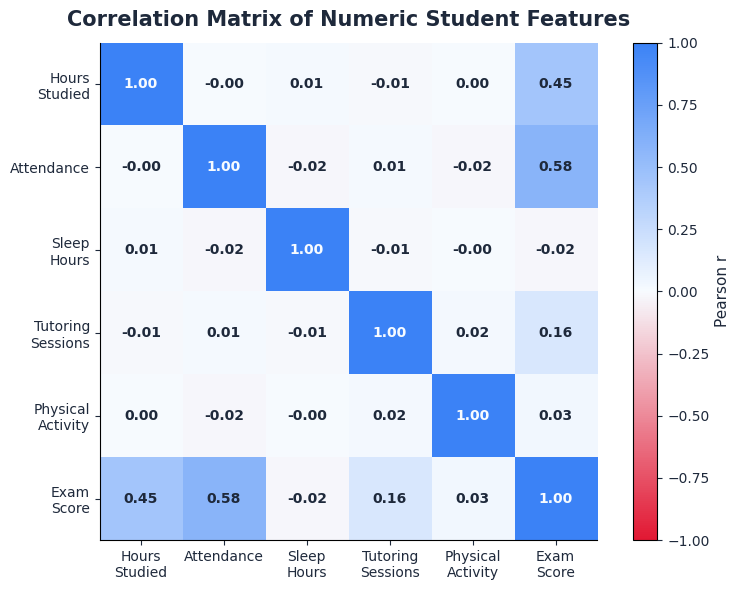

In [378]:
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

# Correlation Matrix
corr_matrix = df[numeric_cols].corr()
print("=== Correlations with Exam Score ===")
print(corr_matrix['Exam_Score'].sort_values(ascending=False))

# Visualize Correlation Matrix
cmap = LinearSegmentedColormap.from_list('custom', [RED, BG, BLUE], N=256)
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(label='Pearson r')

# Plot Design
labels = ['Hours\nStudied', 'Attendance', 'Sleep\nHours',
          'Tutoring\nSessions', 'Physical\nActivity', 'Exam\nScore']
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.title('Correlation Matrix of Numeric Student Features')

# Fill correlation values' labels
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.values[i, j]
        color = BG if abs(val) > 0.6 else DARK
        plt.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# Add weak correlations to "useless" list 
useless = []
useless.append('Sleep_Hours')
useless.append('Physical_Activity')

**Interpretation:** `Attendance` (r = 0.58) and `Hours_Studied` (r = 0.45) are the two strongest numeric predictors of exam score. `Tutoring_Sessions` shows a modest positive relationship (r = 0.16). In contrast, `Sleep_Hours` (r = −0.02) and `Physical_Activity` (r = 0.03) are essentially **uncorrelated** with `Exam_Score`. These are the **useless predictors** among the numeric variables and will be excluded from the regression model.

### 3. Attendance vs. Exam Score

**Hypothesis test:**
- H₀: There is no correlation between attendance and exam score (r = 0)
- H₁: There is a linear correlation between attendance and exam score (r ≠ 0)

Although we know there is a correlation from the heatmap, formality doesn't hurt. We use a hexbin density plot rather than a standard scatter plot because with 6,600+ students, individual points overlap heavily. The hexbin aggregates nearby points into hexagonal bins colored by the number of students, where darker = more students, creating a clean and elegant plot. The red regression line shows the overall trend.

Correlation: 0.5803,  p-value: 0.00e+00
Reject the null hypothesis.


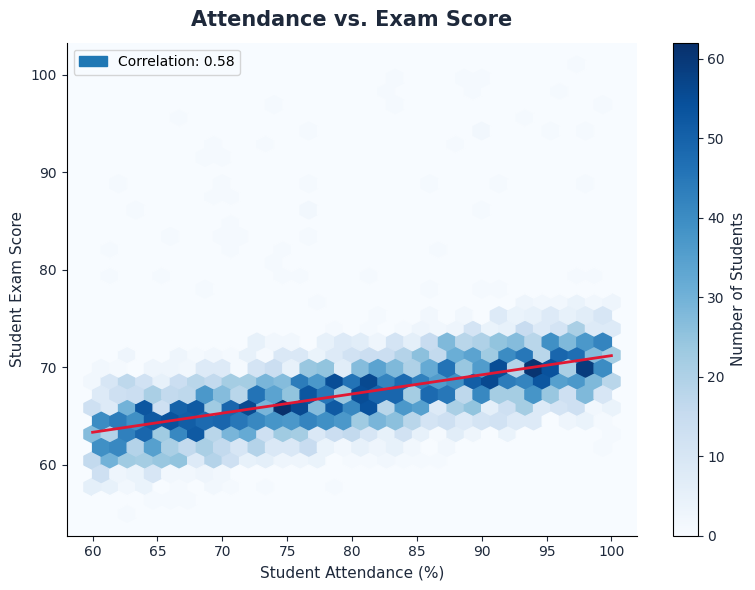

In [379]:
# Pearson correlation test
c, p_val = stats.pearsonr(df["Attendance"], df["Exam_Score"])
print(f"Correlation: {c:.4f},  p-value: {p_val:.2e}")

# Hypothesis Testing
if p_val < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

# Hex Bin
plt.figure(figsize=(8, 6))
plt.hexbin(df["Attendance"], df["Exam_Score"], gridsize=30, cmap='Blues')
plt.colorbar(label="Number of Students")

# Regression Line
m, b = np.polyfit(df["Attendance"], df["Exam_Score"], 1)
x_line = np.linspace(df["Attendance"].min(), df["Attendance"].max(), 100)
plt.plot(x_line, m * x_line + b, color=RED, linewidth=2)

# Plot Design
plt.legend(labels=[f"Correlation: {c:.2f}"], loc="upper left")
plt.title("Attendance vs. Exam Score", fontsize=15, fontweight='bold', pad=12)
plt.xlabel("Student Attendance (%)")
plt.ylabel("Student Exam Score")

plt.tight_layout()
plt.show()

**Interpretation:** The test strongly rejects H₀ (p < 0.001). The hexbin reveals that the bulk of students cluster between 60–100% attendance and 63–72 exam score points. Crucially, students with very low attendance are almost entirely absent from the high-score region, confirming that attendance is not just statistically significant but practically **necessary** for strong performance. `Attendance` is one of the most actionable predictors because it is something students can directly control.

### 4. Attendance × Hours Studied × Exam Score

This scatter plot combines three variables at once: `Attendance` on the x-axis, `Hours_Studied` per week on the y-axis, and `Exam_Score` encoded as a color gradient from red (low) to yellow (mid) to green (high).

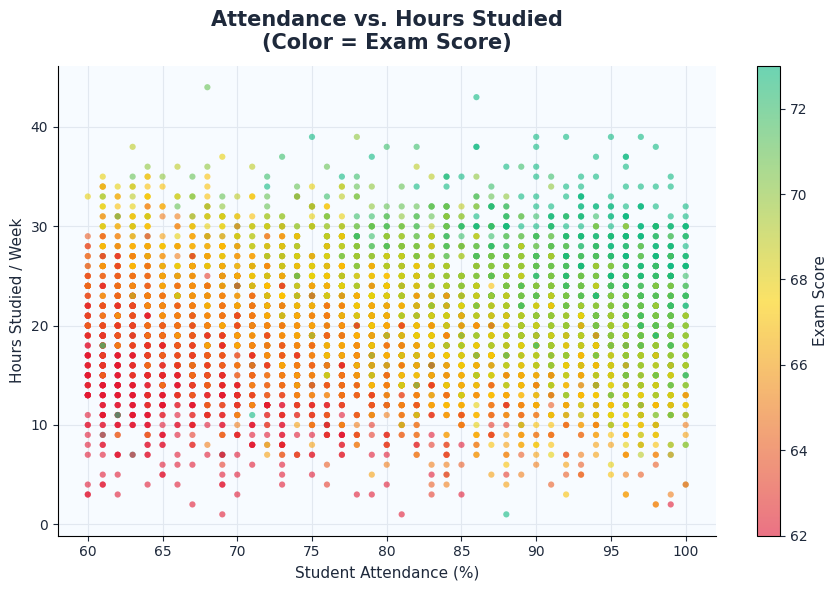

In [380]:
# 3D Scatter Plot
plt.figure(figsize=(9, 6))
score_cmap = LinearSegmentedColormap.from_list('score', [RED, YELLOW, GREEN], N=256)
sc = plt.scatter(df['Attendance'], df['Hours_Studied'], c=df['Exam_Score'], cmap=score_cmap, alpha=0.6, s=20, edgecolors='none',
                vmin=df['Exam_Score'].quantile(0.05), vmax=df['Exam_Score'].quantile(0.95)) # To ignore outliers in color scaling
plt.colorbar(sc, label='Exam Score')

# Plot Design
plt.grid(True)
plt.title('Attendance vs. Hours Studied\n(Color = Exam Score)')
plt.xlabel('Student Attendance (%)')
plt.ylabel('Hours Studied / Week')

plt.tight_layout()
plt.show()

**Interpretation:** Top scorers are overwhelmingly concentrated in the upper-right quadrant; high `Attendance` **and** high `Hours_Studied`. Very few top performers appear in the low-attendance or low-study-hours region, regardless of their other attributes. This confirms that these two behaviors are jointly necessary for top performance, and neither alone is sufficient. The gradient of low on both values as red, high on one or mid on both as yellow, and high on both as green further provides visual evidence.

### 5. Exam Score by Parental Involvement Level (Half Violin)

**Hypothesis test:**
- H₀: Parental involvement has no effect on exam scores (all group means are equal)
- H₁: At least one parental involvement level has a different mean exam score

Moving onto our categorical data (columns with 3 distinct values), we use a one-way ANOVA followed by a Tukey HSD post-hoc test to determine both whether there is an overall effect and which specific pairs of groups differ. The plot combines a half-violin KDE (showing the full score distribution) with nested quantile bands (showing the spread at different percentile ranges). We chose `Parental_Involvement` as an example.

F-statistic: 80.4622, p-value: 3.09e-35
Reject the null hypothesis.


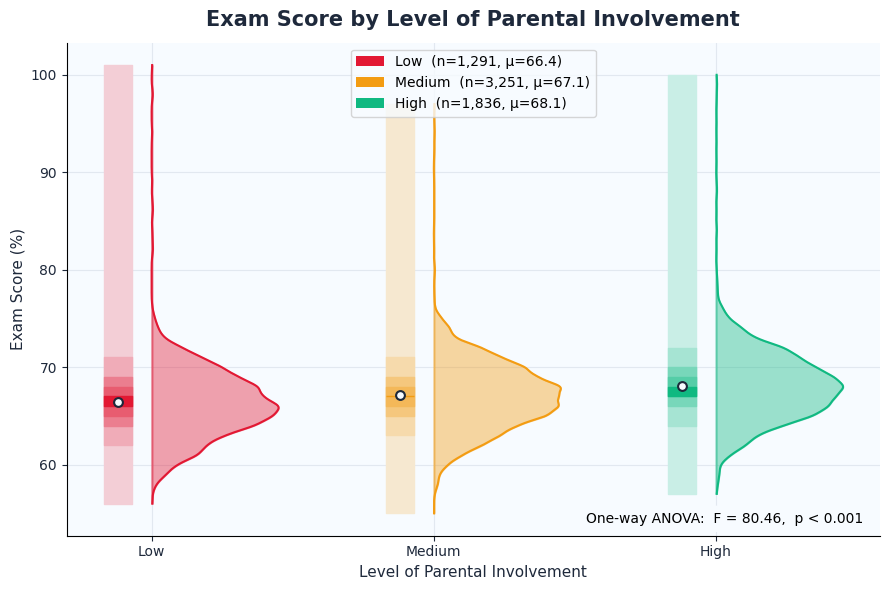

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.7334   0.0 -2.0626 -1.4042   True
  High Medium   -0.999   0.0 -1.2636 -0.7344   True
   Low Medium   0.7344   0.0  0.4363  1.0326   True
---------------------------------------------------


In [381]:
low  = df[df["Parental_Involvement"] == "Low"]["Exam_Score"]
med  = df[df["Parental_Involvement"] == "Medium"]["Exam_Score"]
high = df[df["Parental_Involvement"] == "High"]["Exam_Score"]

# ANOVA Test
f_stat, p_val = stats.f_oneway(low, med, high)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.2e}")

# Hypothesis Testing
if p_val < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

# Preparing for Visualization
groups    = [low, med, high]
labels    = ['Low', 'Medium', 'High']
colors    = [RED, GOLDEN, GREEN]
positions = [1, 2, 3]
quantile_pairs = [(0.00, 1.00), (0.10, 0.90), (0.25, 0.75), (0.35, 0.65), (0.45, 0.55)]
widths         = [0.05, 0.05, 0.05, 0.05, 0.05]
intensities    = [0.20, 0.35, 0.55, 0.7, 1.0]

# Plot Design
plt.figure(figsize=(9, 6))
plt.gcf().patch.set_facecolor('white')
plt.grid(True)

# For each group/value
for pos, group, color in zip(positions, groups, colors):

    # Half Violin Plot
    kde_y = np.linspace(group.min(), group.max(), 500)
    kde_x = stats.gaussian_kde(group, bw_method=0.15)(kde_y)
    kde_x = kde_x / kde_x.max() * 0.45
    plt.fill_betweenx(kde_y, pos, pos + kde_x, alpha=0.4, color=color, zorder=2)
    plt.plot(pos + kde_x, kde_y, color=color, zorder=2)
    plt.vlines(pos, group.min(), group.max(), color=color, linewidth=2, alpha=0.25, zorder=1)

    # Quantile Bands
    band_offset = -0.12
    cmap = LinearSegmentedColormap.from_list('band', [BG, color], N=256)
    for (q_lo, q_hi), w, intensity in zip(quantile_pairs, widths, intensities):
        y_lo = np.quantile(group, q_lo)
        y_hi = np.quantile(group, q_hi)
        plt.fill_betweenx([y_lo, y_hi],
                          pos + band_offset - w,
                          pos + band_offset + w,
                          color=cmap(intensity), zorder=3)
    plt.scatter(pos + band_offset, group.mean(), color=BG, s=40, zorder=4,
                edgecolors=DARK, linewidths=1.5)

# Plot Design
plt.xticks(positions, labels)
plt.title('Exam Score by Level of Parental Involvement')
plt.xlabel('Level of Parental Involvement')
plt.ylabel('Exam Score (%)')

legend_patches = [mpatches.Patch(facecolor=c, 
                  label=f'{l}  (n={len(g):,}, μ={g.mean():.1f})')
                  for c, l, g in zip(colors, labels, groups)]
plt.legend(handles=legend_patches)

plt.text(0.98, 0.02, f'One-way ANOVA:  F = {f_stat:.2f},  p < 0.001',
        transform=plt.gca().transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BG, edgecolor=BG))

plt.tight_layout()
plt.show()

# Tukey post-hoc
tukey_data   = pd.concat([low, med, high])
tukey_labels = ['Low']*len(low) + ['Medium']*len(med) + ['High']*len(high)
tukey = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
print(tukey)

**Interpretation:** The ANOVA is statistically significant (F ≈ 84.5, p < 0.001) and the Tukey post-hoc confirms that **all three pairs differ significantly**. 
However, simply looking at the graph might not fully showcase the differences. Albeit the practical effect is small, with n = 6,600 students the test has enormous statistical power and can detect even trivially small differences. This is a good example of the distinction between *statistical* significance and *practical* significance.

### 6. Effect Size Across Ordered Categorical Factors

While the half violin examines can only examine a single categorical feature, we want to compare the effect of all eight ordered categorical factors at once: `Parental_Involvement`, `Motivation_Level`, `Teacher_Quality`, `Peer_Influence`, `Distance_from_Home`, `Family_Income`, `Parental_Education_Level` and `Access_to_Resources`. The lollipop chart shows the Low-to-High range of mean exam scores for each factor, sorted by total effect size. Each factor is encoded using a Pearson correlation (r) computed by ordinal-encoding Low/Medium/High as 0/1/2. 

An important note is that  three factors use non-standard encodings. Peer_Influence has values Negative/Neutral/Positive, which were encoded as 0/1/2 following the same convention as the other factors. Distance_from_Home has values Far/Moderate/Near, which were reverse-encoded as 2/1/0 and relabeled as "Proximity to Home" so that higher values consistently represent a more "favorable" condition, matching the convention used across all other factors. Parental_Education_Level has values High School/College/Postgraduate, which were encoded as 0/1/2 in order of increasing educational attainment.

A final note is that we have not included ANOVA testing as a) the graph is already full of information b) all 6 are statistically significant and would contribute no meaningful information.

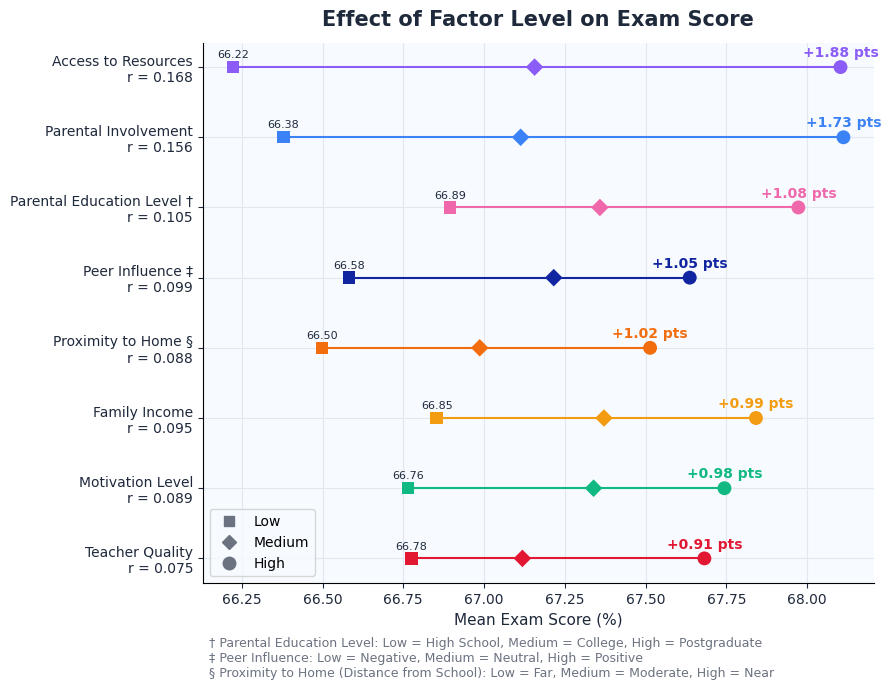

In [382]:
# Setup for categorical factors
encoding = {'Low': 0, 'Medium': 1, 'High': 2}
categories = {
    'Parental_Involvement': {'label': 'Parental Involvement', 'color': BLUE},
    'Motivation_Level':     {'label': 'Motivation Level',     'color': GREEN},
    'Teacher_Quality':      {'label': 'Teacher Quality',      'color': RED},
    'Family_Income':        {'label': 'Family Income',        'color': GOLDEN},
    'Access_to_Resources':  {'label': 'Access to Resources',  'color': PURPLE}
}
levels = ['Low', 'Medium', 'High']

# Collect the means and correlations for each factor, and store
data = {}
for col, meta in categories.items():
    means   = {l: df[df[col] == l]['Exam_Score'].mean() for l in levels}  # Get mean for each level 
    encoded = df[col].map(encoding) # Encode the column as Low=0, Medium=1, High=2 for correlation
    r, _ = stats.pearsonr(encoded, df['Exam_Score'])
    data[col] = { # Store means, correlation, and visualization metadata for each column
        'means': means, 'r': r, 'color': meta['color'], 'label': meta['label'],
    }

# Peer Influence
# Setup
peer_encoding = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
peer_levels = ['Negative', 'Neutral', 'Positive']

# Collect the mean and correlation for Peer Influence, and store 
peer_means  = {l: df[df['Peer_Influence'] == l]['Exam_Score'].mean() for l in peer_levels}
peer_encoded = df['Peer_Influence'].map(peer_encoding)
peer_r, _ = stats.pearsonr(peer_encoded, df['Exam_Score'])
data['Peer_Influence'] = {
    'means':  {'Low': peer_means['Negative'],
               'Medium': peer_means['Neutral'],
               'High': peer_means['Positive']},
    'r':      peer_r,
    'color':  NAVY,
    'label':  'Peer Influence ‡'
}

# Distance from Home
# Setup
dist_encoding    = {'Far': 0, 'Moderate': 1, 'Near': 2}
dist_levels = ['Far', 'Moderate', 'Near'] 

# Collect the mean and correlation for Distance from Home, and store 
dist_means  = {l: df[df['Distance_from_Home'] == l]['Exam_Score'].mean() for l in dist_levels}
dist_encoded = df['Distance_from_Home'].map(dist_encoding)
dist_r, _ = stats.pearsonr(dist_encoded, df['Exam_Score'])
data['Distance_from_Home'] = {
    'means':  {'Low': dist_means['Far'],
               'Medium': dist_means['Moderate'],
               'High': dist_means['Near']},
    'r':      dist_r,
    'color':  ORANGE,
    'label':  'Proximity to Home §',
}

# Parental Education Level
# Setup
edu_encoding    = {'High School': 0, 'College': 1, 'Postgraduate': 2}
edu_levels = ['High School', 'College', 'Postgraduate']

# Collect the mean and correlation for Parental Education Level, and store 
edu_means  = {l: df[df['Parental_Education_Level'] == l]['Exam_Score'].mean() for l in edu_levels}
edu_encoded = df['Parental_Education_Level'].map(edu_encoding)
edu_r, _ = stats.pearsonr(edu_encoded, df['Exam_Score'])
data['Parental_Education_Level'] = {
    'means':  {'Low': edu_means['High School'],
               'Medium': edu_means['College'],
               'High': edu_means['Postgraduate']},
    'r':      edu_r,
    'color':  PINK,
    'label':  'Parental Education Level †',
}

# Visualization of Categorical Factor Effects by Effect Size (High - Low)
sorted_data = sorted(data.items(), key=lambda x: x[1]['means']['High'] - x[1]['means']['Low'])

# Plot Design
plt.figure(figsize=(9, 7))
plt.grid(True)

# Lolipop Plot
y_pos = range(len(sorted_data))

# Draw a line with points for each category, and annotate the low  mean and effect size
for y, (_, d) in zip(y_pos, sorted_data):
    low_mean  = d['means']['Low']
    med_mean  = d['means']['Medium']
    high_mean = d['means']['High']
    color     = d['color']
    effect    = high_mean - low_mean

    plt.hlines(y, low_mean, high_mean, color=color, zorder=1)
    plt.scatter(low_mean,  y, color=color, s=80,  zorder=2, marker='s', edgecolors='none')
    plt.text(low_mean, y + 0.10, f'{low_mean:.2f}', ha='center', va='bottom', fontsize=8, color=DARK)
    plt.scatter(med_mean,  y, color=color, s=80,  zorder=2, marker='D', edgecolors='none')
    plt.scatter(high_mean, y, color=color, s=100, zorder=2, marker='o', edgecolors='none')
    plt.text(high_mean, y + 0.10, f'+{effect:.2f} pts', ha='center', va='bottom', fontweight='bold', color=color)

# Plot Design
plt.yticks(list(y_pos), [f"{d['label']}\nr = {d['r']:.3f}" for _, d in sorted_data])
plt.title('Effect of Factor Level on Exam Score')
plt.xlabel('Mean Exam Score (%)')

# Footnotes for special encodings
plt.text(0.01, -0.1,
        '† Parental Education Level: Low = High School, Medium = College, High = Postgraduate\n'
        '‡ Peer Influence: Low = Negative, Medium = Neutral, High = Positive\n'
        '§ Proximity to Home (Distance from School): Low = Far, Medium = Moderate, High = Near',
        transform=plt.gca().transAxes, fontsize=9, color=GRAY, va='top')
        
legend_shape = [
    Line2D([0], [0], marker='s', color=GRAY, linestyle='none', markersize=7, label='Low'),
    Line2D([0], [0], marker='D', color=GRAY, linestyle='none', markersize=7, label='Medium'),
    Line2D([0], [0], marker='o', color=GRAY, linestyle='none', markersize=9, label='High'),
]
plt.legend(handles=legend_shape)

plt.tight_layout()
plt.show()

useless.append('Teacher_Quality')
useless.append('Motivation_Level')
useless.append('Family_Income')
useless.append('Distance_from_Home')
useless.append('Peer_Influence')

**Interpretation:** `Access_to_Resources` has the largest total effect and the strongest correlation (r = 0.168), followed by `Parental_Involvement` (r = 0.156) and `Parental_Education_Level` (r = 0.105). These three are the only factors that clear our r >= 0.1 significance threshold and will be retained in the regression model. The remaining five factors (`Family_Income`, `Motivation_Level`, `Proximity_to_Home`, `Peer_Influence`, and `Teacher_Quality`) all have correlations below 0.1, explaining less than 1% of the variance in exam scores each, and are excluded as weak predictors.

### 7. Exam Score Distribution by Binary Categorical Factors

This plot examines five binary (two-value) categorical variables simultaneously. For each variable, two mirrored half-violin KDEs are shown side by side: **blue** (left) represents the first value and **red** (right) represents the second. This lets us visually compare how much the exam score distributions shift between the two groups for each factor.

Below each column, a t-test p-value and mean difference (Δ) are annotated directly on the chart.

**Color key:** Blue = Yes / No / Yes / Public / Male — Red = No / Yes / No / Private / Female

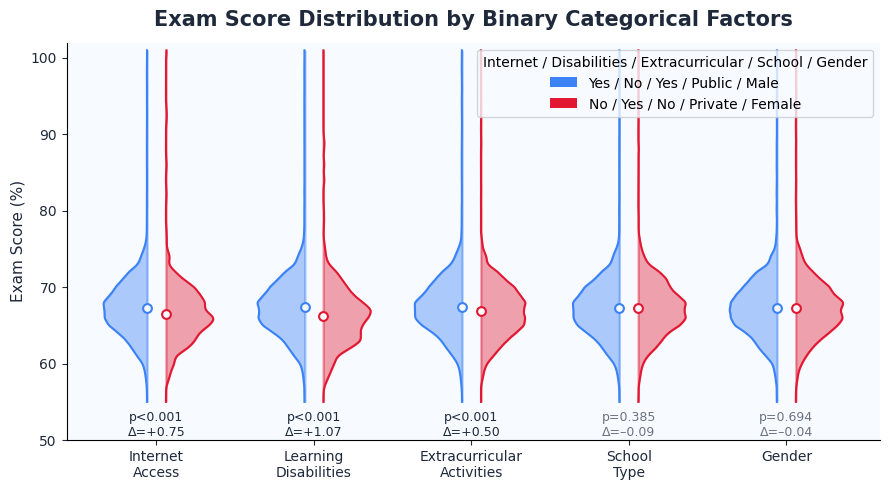

In [383]:
# Setup
binary_cols = [
    ('Internet_Access',            'Internet\nAccess',            'Yes',    'No'),
    ('Learning_Disabilities',      'Learning\nDisabilities',      'No',     'Yes'),
    ('Extracurricular_Activities', 'Extracurricular\nActivities', 'Yes',    'No'),
    ('School_Type',                'School\nType',                'Public', 'Private'),
    ('Gender',                     'Gender',                      'Male',   'Female'),
]

positions = [1, 2, 3, 4, 5]
gap       = 0.06

# Plot Design
plt.figure(figsize=(9, 5))

# For each binary categorical factor, plot the KDE half-violin plots for the two groups, and perform a t-test to compare their means
for pos, (col, title, blue_val, red_val) in zip(positions, binary_cols):

    # Get the Exam_Score values for the two groups defined by the binary column
    g_blue = df[df[col] == blue_val]['Exam_Score']
    g_red  = df[df[col] == red_val]['Exam_Score']

    score_min = df['Exam_Score'].min()
    score_max = df['Exam_Score'].max()

    # KDE for each group
    kde_y      = np.linspace(score_min, score_max, 500)
    kde_blue   = stats.gaussian_kde(g_blue, bw_method=0.15)(kde_y)
    kde_red    = stats.gaussian_kde(g_red,  bw_method=0.15)(kde_y)
    max_kde    = max(kde_blue.max(), kde_red.max())
    kde_blue_n = kde_blue / max_kde * 0.3
    kde_red_n  = kde_red  / max_kde * 0.3

    # Plot Blue
    plt.fill_betweenx(kde_y, pos - gap, pos - gap - kde_blue_n, alpha=0.4, color=BLUE, zorder=2)
    plt.plot(pos - gap - kde_blue_n, kde_y, color=BLUE, zorder=3)
    plt.vlines(pos - gap, score_min, score_max, color=BLUE, linewidth=2, alpha=0.25, zorder=1)

    # Plot Red
    plt.fill_betweenx(kde_y, pos + gap, pos + gap + kde_red_n, alpha=0.4, color=RED, zorder=2)
    plt.plot(pos + gap + kde_red_n, kde_y, color=RED, zorder=3)
    plt.vlines(pos + gap, score_min, score_max, color=RED, linewidth=2, alpha=0.25, zorder=1)

    # Plot mean points
    plt.scatter(pos - gap, g_blue.mean(), color=BG, s=40, zorder=4, edgecolors=BLUE, linewidths=1.5)
    plt.scatter(pos + gap, g_red.mean(), color=BG, s=40, zorder=4, edgecolors=RED, linewidths=1.5)

    # T-test
    t, p_val  = stats.ttest_ind(g_blue, g_red)
    diff  = g_blue.mean() - g_red.mean()
    p_str  = 'p<0.001' if p_val < 0.001 else f'p={p_val:.3f}'
    plt.text(pos, score_min - 1.2, f'{p_str}\nΔ={(f'{diff:+.2f}' if diff >= 0 else f'–{-diff:.2f}')}', ha='center', va='top', fontsize=9, color=(DARK if p_val < 0.05 else GRAY))

# Plot Design
plt.xticks(positions, [b[1] for b in binary_cols])
plt.ylabel('Exam Score (%)')
plt.title('Exam Score Distribution by Binary Categorical Factors')
plt.ylim(50, score_max + 1)


blue_vals = ' / '.join([b[2] for b in binary_cols])
red_vals  = ' / '.join([b[3] for b in binary_cols])
col_names = ' / '.join(['Internet', 'Disabilities', 'Extracurricular', 'School', 'Gender'])

legend_patches = [
    mpatches.Patch(facecolor=BLUE, label=blue_vals),
    mpatches.Patch(facecolor=RED, label=red_vals),
]
plt.legend(handles=legend_patches, title=col_names, loc='upper right')

plt.tight_layout()
plt.show()

useless.append('School_Type')
useless.append('Gender')

**Interpretation:** The most visually striking separation appears in `Learning Disabilities`, where students without learning disabilities score noticeably higher, with the two distributions clearly offset. `Internet_Access` and `Extracurricular_Activities` also show meaningful, significant differences. In contrast, `School_Type` and `Gender` show nearly identical distributions with very small Δ values, confirming these are **weak or useless predictors** for our model. Both will be excluded from the regression.

## Primary Analysis: Linear Regression

Based on our EDA, we identified the following weak or uninformative predictors:
- **`Sleep_Hours`**
- **`Physical_Activity`** 
- **`Teacher_Quality`**
- **`Motivation_Level`**
- **`Family_Income`**
- **`Distance_from_Home`**
- **`Peer_Influence`**
- **`School_Type`** 
- **`Gender`**

We retain all remaining features and use **linear regression** because `Exam_Score` is a continuous numeric variable and our EDA showed roughly linear relationships between the key predictors and the outcome. We use an 80/20 train/test split to evaluate generalization performance.

In [384]:
df_model = df.drop(columns=useless)

# Encode ordered categorical columns as integers
df_model['Parental_Involvement']       = df_model['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_model['Access_to_Resources']        = df_model['Access_to_Resources'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_model['Parental_Education_Level']   = df_model['Parental_Education_Level'].map({'High School': 0, 'College': 1, 'Postgraduate': 2})
df_model['Extracurricular_Activities'] = df_model['Extracurricular_Activities'].map({'No': 0, 'Yes': 1})
df_model['Internet_Access']            = df_model['Internet_Access'].map({'No': 0, 'Yes': 1})
df_model['Learning_Disabilities']      = df_model['Learning_Disabilities'].map({'No': 0, 'Yes': 1})

# Prepare data for modeling
X = df_model.drop(columns=['Exam_Score'])
y = df_model['Exam_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate model performance
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f}  |  RMSE: {rmse:.4f}")

R²: 0.6646  |  RMSE: 2.2829


## Visualization: Model Performance

Two plots assess how well the model performs. The left panel plots predicted scores against actual scores, with points lying on the diagonal represent perfect predictions. The right panel shows the distribution of residuals (actual minus predicted), which should be centered near zero with no systematic pattern if the model is unbiased.

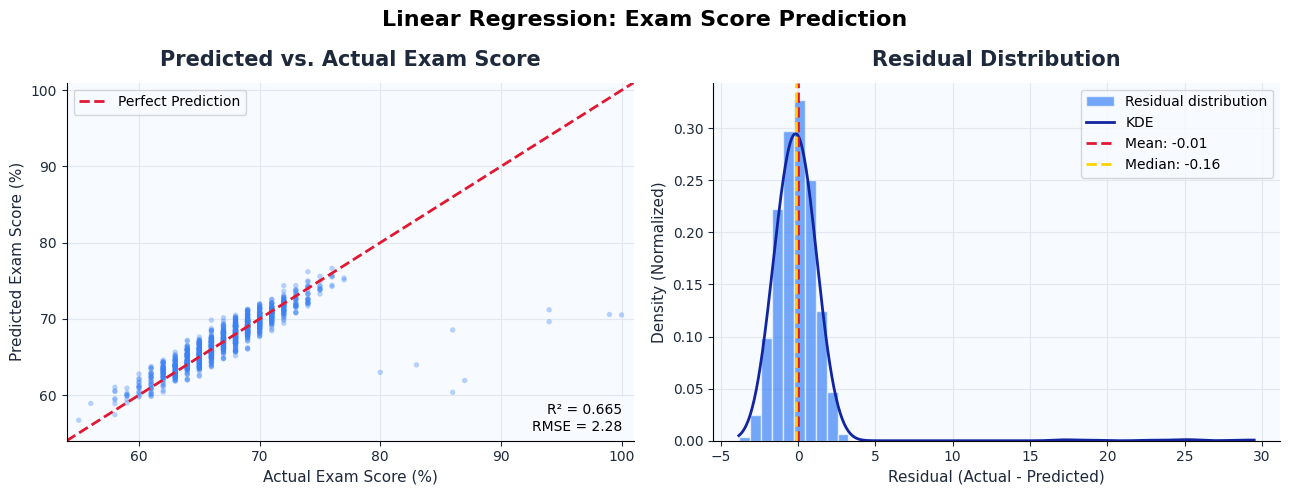

In [385]:
# Plot Design
fig = plt.figure(figsize=(13, 5))
fig.patch.set_facecolor('white')

# Left panel, Predicted vs. Actual
plt.subplot(1, 2, 1)
plt.grid(True)
plt.scatter(y_test, y_pred, alpha=0.35, s=15, color=BLUE, edgecolors='none')
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, color=RED, linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Actual Exam Score (%)')
plt.ylabel('Predicted Exam Score (%)')
plt.title('Predicted vs. Actual Exam Score')
plt.text(0.98, 0.02, f'R² = {r2:.3f}\nRMSE = {rmse:.2f}',
        transform=plt.gca().transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BG, edgecolor=BG))
plt.legend()

# Right panel, Residuals Distribution
plt.subplot(1, 2, 2)
plt.grid(True)

# KDE Plot
residuals = y_test.values - y_pred
plt.hist(residuals, bins=47, color=BLUE, alpha=0.7, edgecolor=BG,
       density=True, label='Residual distribution')
kde_x = np.linspace(residuals.min(), residuals.max(), 500)
plt.plot(kde_x, stats.gaussian_kde(residuals, bw_method=0.3)(kde_x), color=NAVY, linewidth=2, label='KDE')

# Mean and Median lines
plt.axvline(residuals.mean(), color=RED, linestyle='--', linewidth=2,
            label=f'Mean: {residuals.mean():.2f}')
plt.axvline(np.median(residuals), color=YELLOW, linestyle='--', linewidth=2,
            label=f'Median: {np.median(residuals):.2f}')

# Plot Design
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Density (Normalized)')
plt.title('Residual Distribution')
plt.legend()
plt.suptitle('Linear Regression: Exam Score Prediction', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The model achieves **R² ≈ 0.665** and **RMSE ≈ 2.28**, meaning it explains 66.5% of the variance in exam scores with an average prediction error just around 2 points on a 100-point scale. The predicted vs. actual scatter clusters tightly around the diagonal, and the residual distribution is centered near zero with a roughly bell shape, both indicating the model has no major systematic bias.

## Insights and Conclusions

Our analysis shows that a student's exam score can be predicted reasonably well from behavioral and environmental factors alone. The linear regression model achieved an **R² of 0.665**, meaning 66.5% of the variance in exam scores is explained by factors like attendance, access to resources, parental involvement, and internet access. The average prediction error was **just about 2 points** on a 100-point scale.

That said, the model is not perfect — 33.5% of the variance remains unexplained. This is expected given that our dataset does not capture everything that influences a student's performance. Factors like **mental health, quality of curriculum, home stability, or personal interests** are difficult to measure but likely play a significant role. This model is more of a prototype; the methodology is sound, but a production version with richer, real-world data and more features would perform considerably better.

And that is exactly where this approach gets interesting. Tests like **MAP** are widely administered to middle and high school students to measure academic growth. MAP requires dedicated testing sessions, creates student stress, and produces results that tell a student they are "below grade level" without explaining why or what to do about it. Our approach flips that: instead of sitting a student down for a high-stakes exam, you give them a short survey covering their study habits, attendance, home environment, and access to resources. The model predicts how they are likely to perform and, more importantly, generates a **personalized improvement report**.

The report works by computing a potential gain score for each factor:

> **potential_gain = (max_value − student_current_value) × model_coefficient**

This tells you exactly which factors have the most room to improve and the highest impact on the predicted score for that specific student. A student who already attends class regularly gets no recommendation there, instead the report surfaces the factors where they are actually falling short. A parent might learn their child needs better access to learning resources at home. A teacher might see that a student lacks peer support. These are **concrete, actionable insights** rather than a percentile ranking.

Compared to MAP, this method saves time, reduces testing costs, and eliminates the stress of a formal exam. More importantly, it produces advice that is specific to each student rather than a generic score. A complete version of this model trained on real school data could serve as a practical early intervention tool, identifying struggling students before they fall too far behind, and giving educators and parents exactly the information they need to help.